# ECO Dataset Exploration
**Structure discovered:**
- Smart meter: 16 cols, 1Hz, one CSV per day
- Plugs: 1 col, 1Hz, one CSV per day  
- Occupancy: wide format — rows=days, cols=seconds (86400), values=0/1

## 0. Setup & Paths

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DRIVE = '/content/drive/MyDrive/Colab_Notebooks/ECO_Dataset/'

# Adjust these if your folder names differ
HOUSES = {
    '01': {
        'sm':  f'{DRIVE}01_sm_csv/01',
        'plugs': f'{DRIVE}01_plugs_csv/01', # Modified to point to the parent directory of plug subfolders
        'occ':  f'{DRIVE}01_occupancy_csv',
    },
    '02': {
        'sm':  f'{DRIVE}02_sm_csv/02',
        'plugs': f'{DRIVE}02_plugs_csv/02',
        'occ':  f'{DRIVE}02_occupancy_csv',
    },
    '04': {
        'sm':  f'{DRIVE}04_sm_csv/04_sm_csv/04',
        'plugs': f'{DRIVE}04_plugs_csv/04',
        'occ':  f'{DRIVE}04_occupancy_csv',
    },
}

# ECO smart meter column names (from official documentation)
SM_COLS = [
    'power_active',    # W  — this is our main signal
    'power_reactive',  # VAR
    'power_apparent',  # VA
    'power_factor',
    'voltage_rms',
    'current_rms',
    'freq',
    'phase1_active', 'phase1_reactive', 'phase1_apparent',
    'phase2_active', 'phase2_reactive', 'phase2_apparent',
    'phase3_active', 'phase3_reactive', 'phase3_apparent',
]

for h, paths in HOUSES.items():
    sm_n   = len(os.listdir(paths['sm']))
    # For plugs, we are now listing plug subfolders, not daily CSVs directly.
    # So this count will be the number of plug subfolders, not days of data for a single plug.
    pl_n   = len(os.listdir(paths['plugs']))
    occ_n  = len(os.listdir(paths['occ']))
    print(f'House {h}: SM={sm_n} days, Plugs={pl_n} plug subfolders, Occ={occ_n} files')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
House 01: SM=245 days, Plugs=8 plug subfolders, Occ=2 files
House 02: SM=244 days, Plugs=12 plug subfolders, Occ=2 files
House 04: SM=219 days, Plugs=8 plug subfolders, Occ=2 files


## 1. Smart Meter Loader (1Hz → 1-min resampled)

In [20]:
def load_sm(sm_folder, resample_freq='1min', power_col='power_active'):
    """
    Load all daily smart meter CSVs, concatenate, resample.
    Returns a pandas Series of active power (W) at 1-min resolution.
    """
    files = sorted([
        f for f in os.listdir(sm_folder)
        if f.endswith('.csv')
    ])
    print(f'  Loading {len(files)} SM files...')

    frames = []
    for fname in files:
        date_str = fname.replace('.csv', '')
        try:
            df = pd.read_csv(
                os.path.join(sm_folder, fname),
                header=None,
                names=SM_COLS,
                low_memory=False
            )
            # Build 1Hz datetime index for this day
            start = pd.Timestamp(date_str)
            idx   = pd.date_range(start, periods=len(df), freq='1s')
            df.index = idx
            frames.append(df[[power_col]].astype(float))
        except Exception as e:
            print(f'  Skipping {fname}: {e}')

    if not frames:
        raise ValueError('No files loaded!')

    full  = pd.concat(frames)
    full  = full.clip(lower=0)                  # remove negatives
    resampled = full.resample(resample_freq).mean().dropna()
    print(f'  Done: {len(resampled):,} rows at {resample_freq} resolution')
    print(f'  Range: {resampled.index.min()} → {resampled.index.max()}')
    return resampled[power_col]


print('Loading House 01 smart meter...')
sm_01 = load_sm(HOUSES['01']['sm'])
print(f'\nMean power: {sm_01.mean():.1f} W')
print(f'Max power:  {sm_01.max():.1f} W\n')

print('\nLoading House 02 smart meter...')
sm_02 = load_sm(HOUSES['02']['sm'])
print(f'\nMean power: {sm_02.mean():.1f} W')
print(f'Max power:  {sm_02.max():.1f} W\n')

print('\nLoading House 04 smart meter...')
sm_04 = load_sm(HOUSES['04']['sm'])
print(f'\nMean power: {sm_04.mean():.1f} W')
print(f'Max power:  {sm_04.max():.1f} W')

Loading House 01 smart meter...
  Loading 245 SM files...
  Done: 352,800 rows at 1min resolution
  Range: 2012-06-01 00:00:00 → 2013-01-31 23:59:00

Mean power: 282.0 W
Max power:  8700.7 W


Loading House 02 smart meter...
  Loading 244 SM files...
  Done: 351,360 rows at 1min resolution
  Range: 2012-06-01 00:00:00 → 2013-01-31 23:59:00

Mean power: 210.4 W
Max power:  5180.0 W


Loading House 04 smart meter...
  Loading 219 SM files...
  Done: 315,360 rows at 1min resolution
  Range: 2012-06-27 00:00:00 → 2013-01-31 23:59:00

Mean power: 827.4 W
Max power:  10426.5 W


## 2. Occupancy Loader

In [23]:
def load_occupancy(occ_folder, resample_freq='1min'):
    """
    Load ECO occupancy files.
    Format: rows=days, cols=seconds (86400), values=0/1
    Row 0 = time labels ('00:00:00' ... '23:59:59')
    Col 0 = date strings ('15-Jul-2012' ...)
    Returns a pandas Series of occupancy (0/1) resampled to 1-min.
    """
    files = sorted([
        f for f in os.listdir(occ_folder)
        if f.endswith('.csv')
    ])
    print(f'  Occupancy files: {files}')

    frames = []
    for fname in files:
        try:
            df = pd.read_csv(
                os.path.join(occ_folder, fname),
                header=None,
                low_memory=False
            )
        except Exception as e:
            print(f'  Error reading file {fname}: {e}')
            continue # Skip to next file if read_csv fails

        # Row 0 = time headers, col 0 = dates
        # Skip row 0 (time labels), use col 0 as date index
        data   = df.iloc[1:].copy()     # skip header row
        dates  = data.iloc[:, 0]        # first col = date strings
        values = data.iloc[:, 1:]       # cols 1..86400 = 1Hz occupancy

        if data.empty:
            print(f'  Warning: File {fname} has no data rows after header. Skipping.')
            continue

        for i, (date_str, row) in enumerate(zip(dates, values.values)):
            try:
                date_str = str(date_str).strip()
                start    = pd.to_datetime(date_str, dayfirst=True)
                # Corrected: Use np.nan_to_num for numpy arrays instead of .fillna()
                occ_vals = np.nan_to_num(pd.to_numeric(row, errors='coerce'), nan=0)
                idx      = pd.date_range(start, periods=len(occ_vals), freq='1s')
                s        = pd.Series(occ_vals, index=idx)
                frames.append(s)
            except Exception as e:
                # Modified to print the specific error instead of silently passing
                print(f'  Skipping row with date "{date_str}" in file {fname} due to error: {e}')
                pass # Continue to the next row

    if not frames:
        raise ValueError('No occupancy data loaded! All files or rows failed to parse.') # More descriptive error

    full      = pd.concat(frames).sort_index()
    resampled = full.resample(resample_freq).mean()
    # Round: >0.5 = occupied, ≤0.5 = unoccupied
    resampled = (resampled > 0.5).astype(int)
    resampled = resampled.dropna()
    print(f'  Occupancy: {len(resampled):,} rows')
    print(f'  Range: {resampled.index.min()} → {resampled.index.max()}')

    return resampled


def analyze_occupancy(occ_series, house_id):
    print(f'\n--- House {house_id} Occupancy Analysis ---')
    # Overall
    overall_occ_rate = occ_series.mean() * 100
    print(f'  Overall occupied: {overall_occ_rate:.1f}% of time')

    # Summer (June, July, August)
    summer_months = [6, 7, 8]
    summer_occ = occ_series[occ_series.index.month.isin(summer_months)]
    if not summer_occ.empty:
        summer_occ_rate = summer_occ.mean() * 100
        print(f'  Summer (Jun-Aug) occupied: {summer_occ_rate:.1f}% of time ({len(summer_occ.index.normalize().unique())} days)')
    else:
        print('  No summer occupancy data available.')

    # Winter (December, January, February)
    winter_months = [12, 1, 2]
    winter_occ = occ_series[occ_series.index.month.isin(winter_months)]
    if not winter_occ.empty:
        winter_occ_rate = winter_occ.mean() * 100
        print(f'  Winter (Dec-Feb) occupied: {winter_occ_rate:.1f}% of time ({len(winter_occ.index.normalize().unique())} days)')
    else:
        print('  No winter occupancy data available.')


print('Loading House 01 occupancy...')
occ_01 = load_occupancy(HOUSES['01']['occ'])
analyze_occupancy(occ_01, '01')

print('\nLoading House 02 occupancy...')
occ_02 = load_occupancy(HOUSES['02']['occ'])
analyze_occupancy(occ_02, '02')

print('\nLoading House 04 occupancy...')
occ_04 = load_occupancy(HOUSES['04']['occ'])
analyze_occupancy(occ_04, '04')


Loading House 01 occupancy...
  Occupancy files: ['01_summer.csv', '01_winter.csv']
  Occupancy: 257,760 rows
  Range: 2012-07-15 00:00:00 → 2013-01-09 23:59:00

--- House 01 Occupancy Analysis ---
  Overall occupied: 37.3% of time
  Summer (Jun-Aug) occupied: 66.8% of time (48 days)
  Winter (Dec-Feb) occupied: 71.3% of time (40 days)

Loading House 02 occupancy...
  Occupancy files: ['02_summer.csv', '02_winter.csv']
  Occupancy: 332,640 rows
  Range: 2012-05-30 00:00:00 → 2013-01-15 23:59:00

--- House 02 Occupancy Analysis ---
  Overall occupied: 40.5% of time
  Summer (Jun-Aug) occupied: 65.2% of time (92 days)
  Winter (Dec-Feb) occupied: 67.8% of time (46 days)

Loading House 04 occupancy...
  Occupancy files: ['04_summer.csv', '04_winter.csv']
  Occupancy: 246,240 rows
  Range: 2012-07-25 00:00:00 → 2013-01-11 23:59:00

--- House 04 Occupancy Analysis ---
  Overall occupied: 47.0% of time
  Summer (Jun-Aug) occupied: 82.8% of time (38 days)
  Winter (Dec-Feb) occupied: 80.6% of

## 3. Plug Loader

In [29]:
def load_plug(base_plugs_folder, plug_num, resample_freq='1min'):
    """
    Load a single plug from daily CSVs.
    Plug CSVs have a single column of power values at 1Hz.

    Args:
        base_plugs_folder (str): Path to the directory containing subfolders for each plug (e.g., '01', '02').
        plug_num (int): Integer, 1-indexed, representing the plug ID and corresponding to the subfolder name.
        resample_freq (str): The frequency to resample the data to (e.g., '1min').

    Returns:
        pd.Series: Resampled power data for the specified plug.
    """
    # Construct the path to the specific plug's data folder
    plug_specific_folder = os.path.join(base_plugs_folder, str(plug_num).zfill(2))

    if not os.path.exists(plug_specific_folder):
        print(f"  Plug folder not found for plug {plug_num}: {plug_specific_folder}")
        return pd.Series(dtype=float) # Return empty series if folder doesn't exist

    files = sorted([
        f for f in os.listdir(plug_specific_folder)
        if f.endswith('.csv')
    ])

    if not files:
        print(f"  No CSV files found in plug folder: {plug_specific_folder}")
        return pd.Series(dtype=float)

    print(f'  Plug {plug_num}: Length {len(files)} daily files...')

    frames = []
    for fname in files:
        date_str = fname.replace('.csv', '')
        try:
            df  = pd.read_csv(
                os.path.join(plug_specific_folder, fname), # Use plug_specific_folder
                header=None,
                names=['power'],
                low_memory=False
            )
            start = pd.Timestamp(date_str)
            idx   = pd.date_range(start, periods=len(df), freq='1s')
            df.index = idx
            frames.append(df['power'].astype(float))
        except Exception as e:
            print(f'  Skipping file {fname} in {plug_specific_folder}: {e}')
            pass

    if not frames:
        print(f'  No valid data loaded for plug {plug_num}.')
        return pd.Series(dtype=float)

    full      = pd.concat(frames).clip(lower=0)
    resampled = full.resample(resample_freq).mean().dropna()
    print(f'  Plug {plug_num}: {len(resampled):,} rows at {resample_freq} resolution')
    print(f'  Range: {resampled.index.min()} \u2192 {resampled.index.max()}')
    return resampled


# --- Load and analyze plug data for all houses ---
for house_id, paths in HOUSES.items():
    print(f'\nProcessing plugs for House {house_id}...')
    base_plugs_folder = paths['plugs']

    plug_subfolders = sorted([f for f in os.listdir(base_plugs_folder) if os.path.isdir(os.path.join(base_plugs_folder, f))])

    if plug_subfolders:
        print(f'  Found plug subfolders in House {house_id}: {plug_subfolders}')
        for plug_num_str in plug_subfolders:
            current_plug_num = int(plug_num_str)
            print(f'  Loading data for Plug {current_plug_num} of House {house_id}...')
            plug_data = load_plug(base_plugs_folder, current_plug_num)
            if not plug_data.empty:
                print(f'  Mean power for Plug {current_plug_num}: {plug_data.mean():.1f} W')
                print(f'  Max power for Plug {current_plug_num}:  {plug_data.max():.1f} W')
            else:
                print(f'  No data loaded for Plug {current_plug_num}.')
    else:
        print(f'  No plug subfolders found for House {house_id}. Please check the directory structure.')


Processing plugs for House 01...
  Found plug subfolders in House 01: ['01', '02', '03', '04', '05', '06', '07']
  Loading data for Plug 1 of House 01...
  Plug 1: Length 231 daily files...
  Plug 1: 332,640 rows at 1min resolution
  Range: 2012-06-01 00:00:00 → 2013-01-23 23:59:00
  Mean power for Plug 1: 20.7 W
  Max power for Plug 1:  129.1 W
  Loading data for Plug 2 of House 01...
  Plug 2: Length 231 daily files...
  Plug 2: 332,640 rows at 1min resolution
  Range: 2012-06-01 00:00:00 → 2013-01-23 23:59:00
  Mean power for Plug 2: 22.6 W
  Max power for Plug 2:  898.8 W
  Loading data for Plug 3 of House 01...
  Plug 3: Length 113 daily files...
  Plug 3: 162,720 rows at 1min resolution
  Range: 2012-09-15 00:00:00 → 2013-01-23 23:59:00
  Mean power for Plug 3: 4.6 W
  Max power for Plug 3:  1262.9 W
  Loading data for Plug 4 of House 01...
  Plug 4: Length 203 daily files...
  Plug 4: 292,320 rows at 1min resolution
  Range: 2012-06-01 00:00:00 → 2013-01-23 23:59:00
  Mean powe

## 4. Merge SM + Occupancy & Basic EDA

In [42]:
# Align SM and occupancy on shared time index
sm  = {'01': sm_01, '02': sm_02, '04': sm_04}
occ = {'01': occ_01, '02': occ_02, '04': occ_04}

df = {'01': None, '02': None, '04': None}

for id in ['01', '02', '04']:
    df[id] = pd.DataFrame({
        'power':     sm[id],
        'occupied':  occ[id],
    }).dropna()

    print(f'\n\tCombined dataset of House {id}: {len(df[id]):,} rows')
    print(f'Date range: {df[id].index.min()} → {df[id].index.max()}')
    print(f'Occupied rows:   {df[id].occupied.sum():,} ({df[id].occupied.mean()*100:.1f}%)')
    print(f'Unoccupied rows: {(1-df[id].occupied).sum():,} ({(1-df[id].occupied).mean()*100:.1f}%)')
    print('\t--- Power stats by occupancy state ---')
    print(df[id].groupby('occupied')['power'].describe().round(1))




	Combined dataset of House 01: 257,760 rows
Date range: 2012-07-15 00:00:00 → 2013-01-09 23:59:00
Occupied rows:   96,204.0 (37.3%)
Unoccupied rows: 161,556.0 (62.7%)
	--- Power stats by occupancy state ---
             count   mean    std  min   25%    50%    75%     max
occupied                                                         
0.0       161556.0  261.2  467.4  0.0  88.3  120.4  197.6  8391.4
1.0        96204.0  324.3  523.5  0.0  97.9  142.4  278.5  8700.7

	Combined dataset of House 02: 328,320 rows
Date range: 2012-06-01 00:00:00 → 2013-01-15 23:59:00
Occupied rows:   133,341.0 (40.6%)
Unoccupied rows: 194,979.0 (59.4%)
	--- Power stats by occupancy state ---
             count   mean    std  min   25%    50%    75%     max
occupied                                                         
0.0       194979.0  178.2  280.0  0.0  60.3  102.1  169.3  5180.0
1.0       133341.0  256.7  355.0  0.0  90.4  159.8  326.2  5086.9

	Combined dataset of House 04: 246,240 rows
Date range

## 5. Occupancy vs Power — Core Analysis


--- Generating EDA Plots for House 01 ---


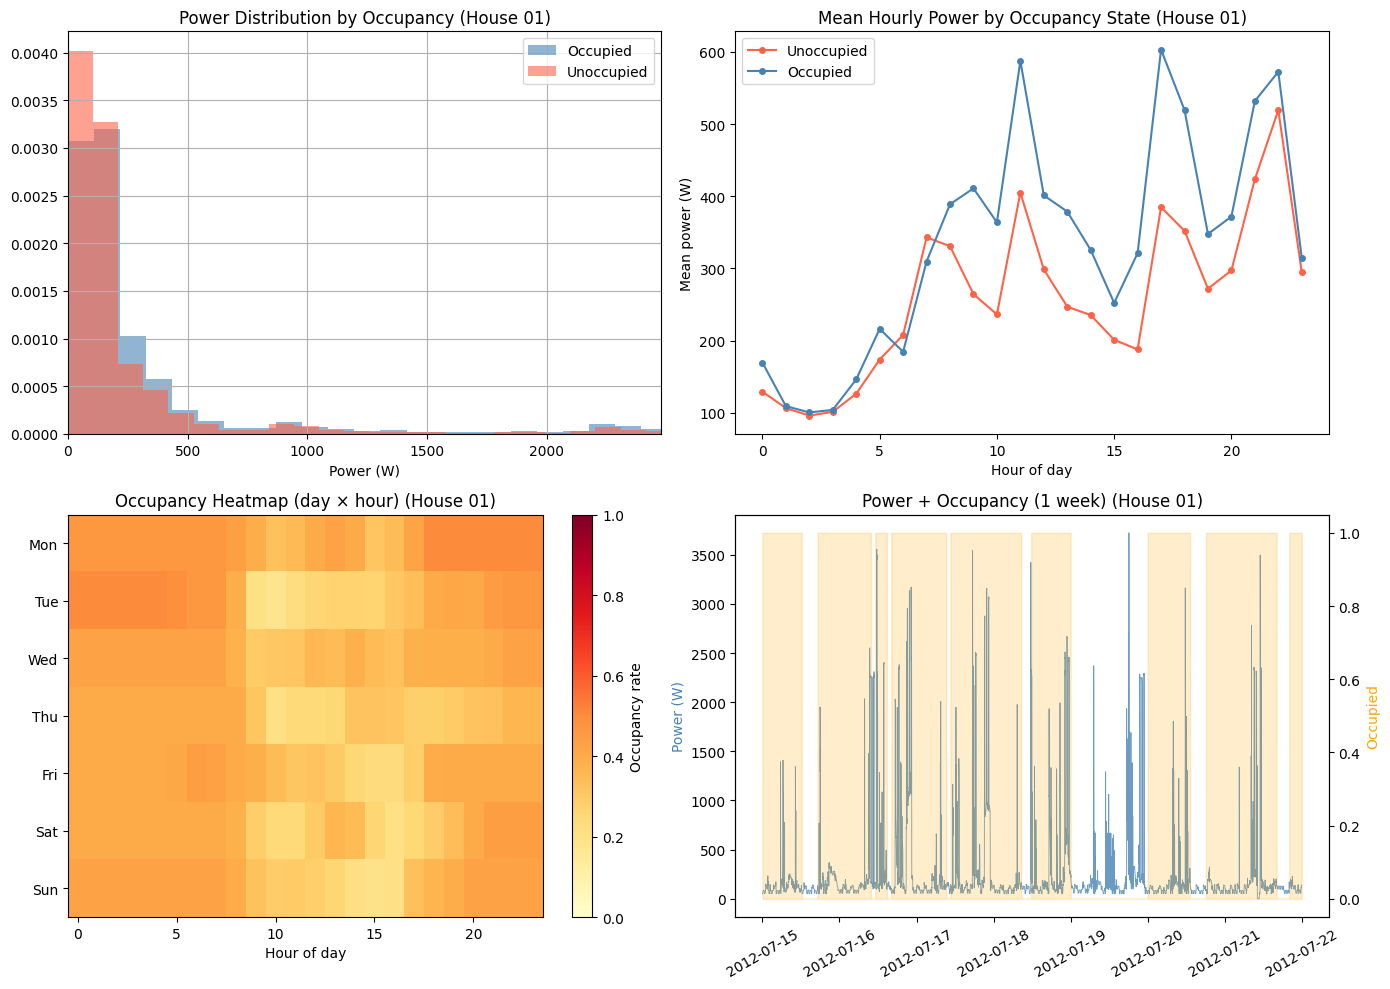

Plots for House 01 saved.

--- Generating EDA Plots for House 02 ---


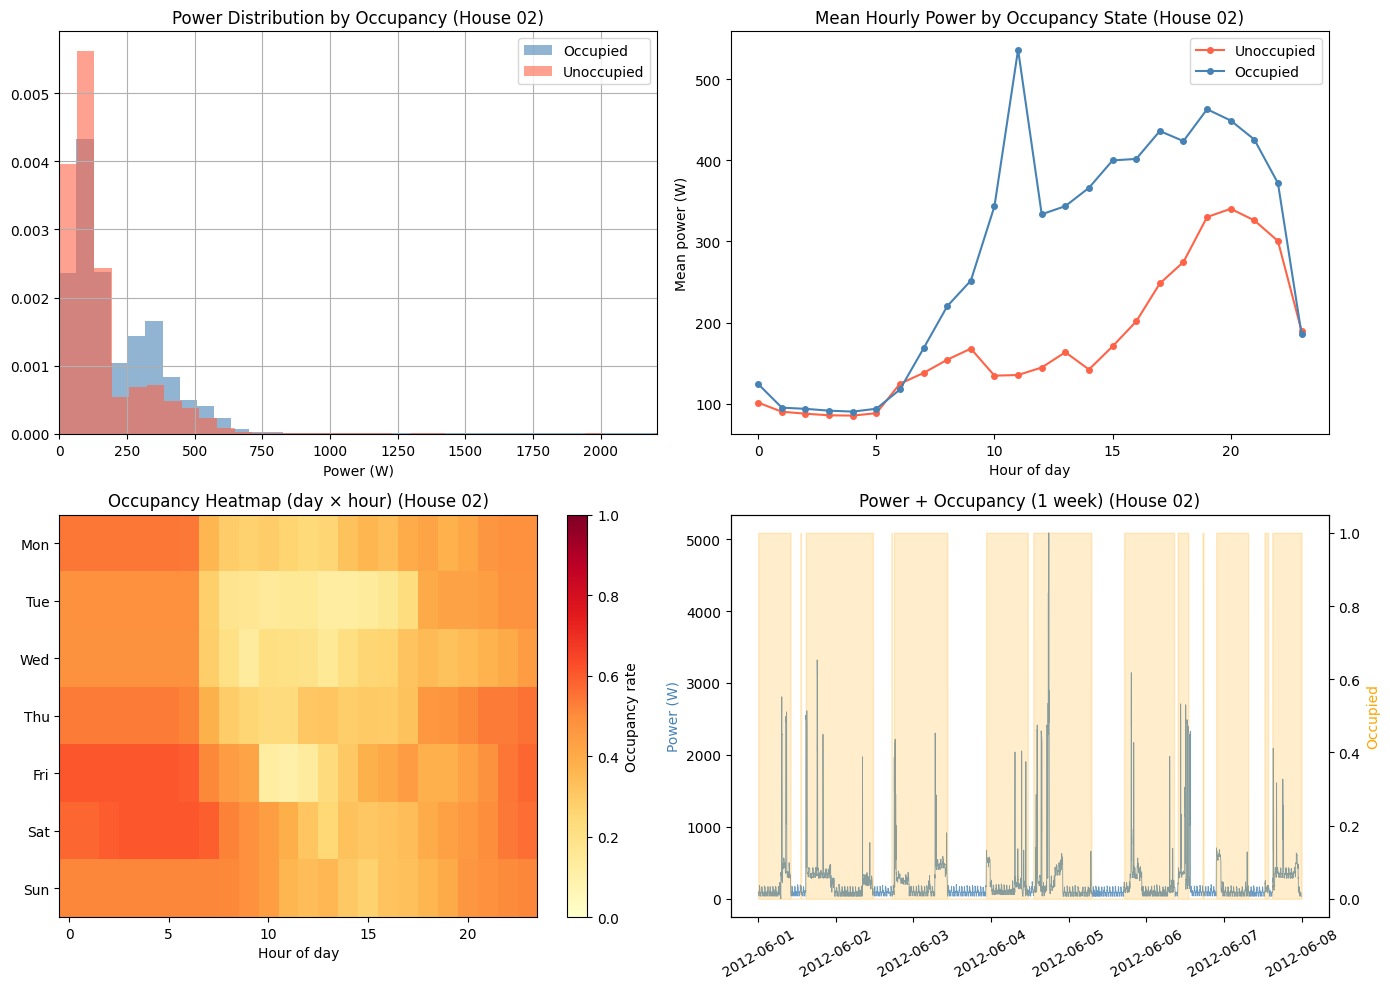

Plots for House 02 saved.

--- Generating EDA Plots for House 04 ---


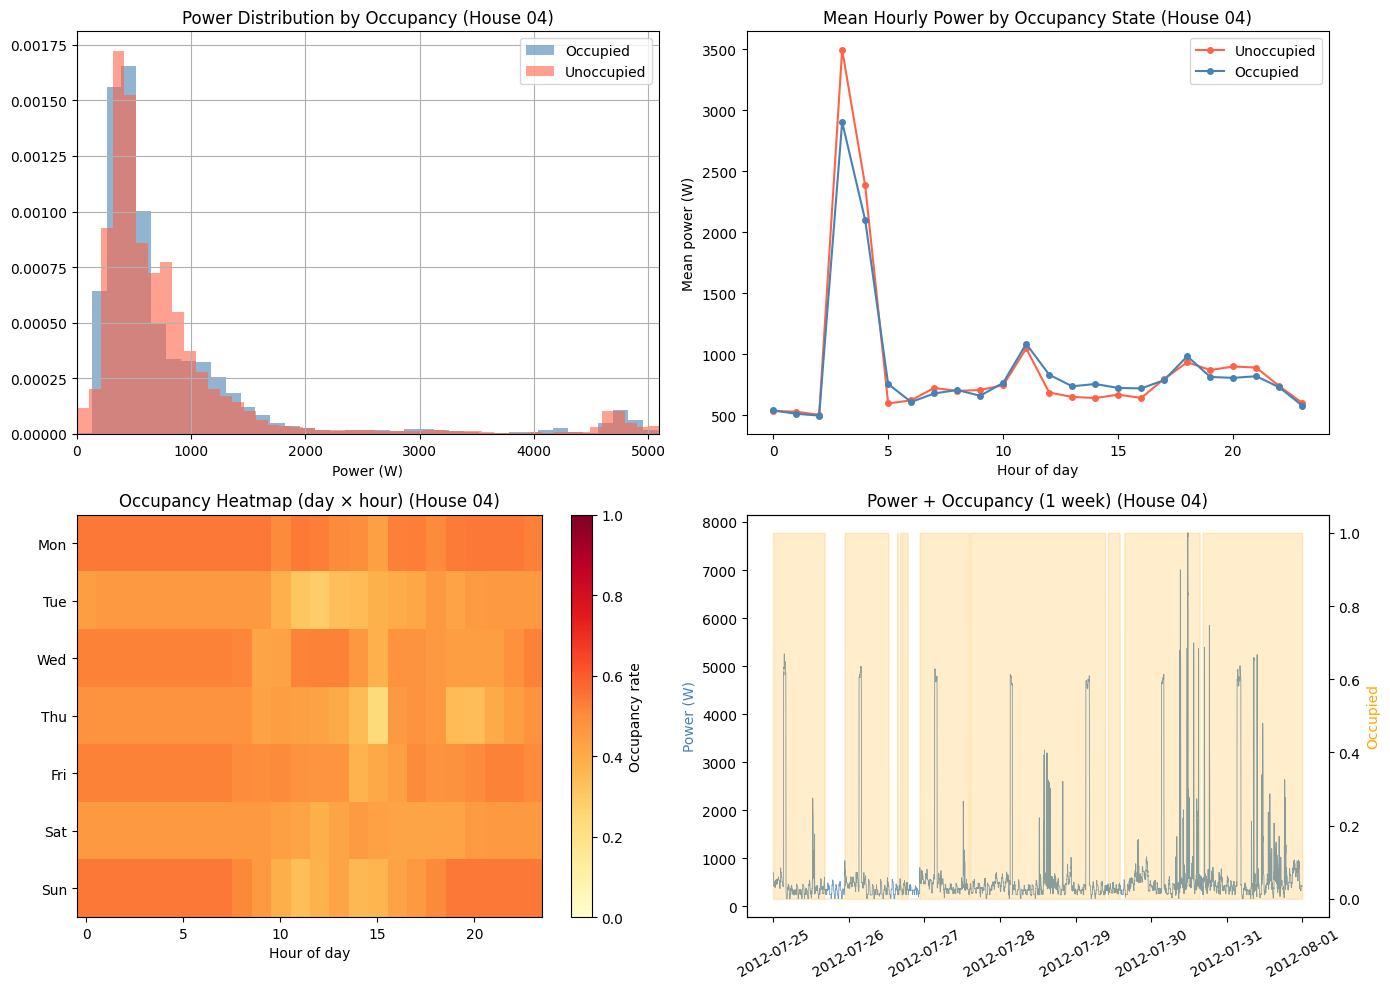

Plots for House 04 saved.


In [44]:
for house_id, current_df in df.items():
    print(f'\n--- Generating EDA Plots for House {house_id} ---')
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1 — Power distribution by occupancy state
    ax = axes[0, 0]
    if not current_df[current_df.occupied == 1].empty:
        current_df[current_df.occupied == 1]['power'].hist(
            bins=80, alpha=0.6, color='steelblue', label='Occupied', ax=ax, density=True)
    if not current_df[current_df.occupied == 0].empty:
        current_df[current_df.occupied == 0]['power'].hist(
            bins=80, alpha=0.6, color='tomato', label='Unoccupied', ax=ax, density=True)
    ax.set_xlabel('Power (W)')
    ax.set_title(f'Power Distribution by Occupancy (House {house_id})')
    ax.legend()
    if not current_df.empty:
        ax.set_xlim(0, current_df['power'].quantile(0.99))

    # 2 — Mean hourly power by occupancy
    ax = axes[0, 1]
    current_df['hour'] = current_df.index.hour
    hourly = current_df.groupby(['hour', 'occupied'])['power'].mean().unstack()
    if 0 in hourly.columns:
        hourly[0].plot(ax=ax, color='tomato', label='Unoccupied', marker='o', ms=4)
    if 1 in hourly.columns:
        hourly[1].plot(ax=ax, color='steelblue', label='Occupied', marker='o', ms=4)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Mean power (W)')
    ax.set_title(f'Mean Hourly Power by Occupancy State (House {house_id})')
    ax.legend()

    # 3 — Weekly occupancy pattern
    ax = axes[1, 0]
    current_df['dayofweek'] = current_df.index.dayofweek  # 0=Mon, 6=Sun
    daily_occ = current_df.groupby(['dayofweek', 'hour'])['occupied'].mean().unstack()
    if not daily_occ.empty:
        im = ax.imshow(daily_occ, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
        ax.set_yticks(range(7))
        ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
        ax.set_xlabel('Hour of day')
        ax.set_title(f'Occupancy Heatmap (day × hour) (House {house_id})')
        plt.colorbar(im, ax=ax, label='Occupancy rate')
    else:
        ax.text(0.5, 0.5, 'No Daily Occupancy Data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)


    # 4 — 1 week time series sample
    ax = axes[1, 1]
    if not current_df.empty:
        sample = current_df.iloc[:60*24*7]   # 1 week
        if not sample.empty:
            ax2 = ax.twinx()
            ax.plot(sample.index, sample['power'], color='steelblue', lw=0.6, alpha=0.8)
            ax2.fill_between(sample.index, sample['occupied'],
                             alpha=0.2, color='orange', label='Occupied')
            ax.set_ylabel('Power (W)', color='steelblue')
            ax2.set_ylabel('Occupied', color='orange')
            ax.set_title(f'Power + Occupancy (1 week) (House {house_id})')
            ax.tick_params(axis='x', rotation=30)
        else:
            ax.text(0.5, 0.5, 'No Sample Data for Time Series', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, 'No Data Available', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

    plt.tight_layout()
    plt.savefig(f'/tmp/eco_eda_house{house_id}.png', dpi=120)
    plt.show()
    print(f'Plots for House {house_id} saved.')


## 6. Occupancy Scaling Factors

In [14]:
# Core finding: how much does occupancy change power consumption?
mean_occupied   = df[df.occupied == 1]['power'].mean()
mean_unoccupied = df[df.occupied == 0]['power'].mean()
scaling_factor  = mean_occupied / mean_unoccupied

print('=== Occupancy Scaling Analysis — House 01 ===')
print(f'Mean power (occupied)   : {mean_occupied:.1f} W')
print(f'Mean power (unoccupied) : {mean_unoccupied:.1f} W')
print(f'Occupancy scaling factor: {scaling_factor:.2f}x')
print(f'  → House uses {scaling_factor:.1f}x more power when occupied')

# Per-hour scaling
print('\n--- Hourly occupancy scaling factors ---')
hourly_scale = hourly[1] / hourly[0].replace(0, np.nan)
hourly_scale = hourly_scale.fillna(1.0)
print(hourly_scale.round(2).to_string())

# Save for later use in simulation engine
scaling_stats = {
    'house':             '01',
    'mean_occupied_W':   round(mean_occupied, 1),
    'mean_unoccupied_W': round(mean_unoccupied, 1),
    'scaling_factor':    round(scaling_factor, 3),
    'baseline_idle_W':   round(mean_unoccupied, 1),
}
print('\nScaling stats (save for simulation engine):')
for k, v in scaling_stats.items():
    print(f'  {k}: {v}')

=== Occupancy Scaling Analysis — House 01 ===
Mean power (occupied)   : 324.3 W
Mean power (unoccupied) : 261.2 W
Occupancy scaling factor: 1.24x
  → House uses 1.2x more power when occupied

--- Hourly occupancy scaling factors ---
hour
0     1.31
1     1.03
2     1.05
3     1.03
4     1.16
5     1.24
6     0.89
7     0.90
8     1.18
9     1.55
10    1.54
11    1.45
12    1.34
13    1.53
14    1.38
15    1.25
16    1.71
17    1.57
18    1.48
19    1.28
20    1.25
21    1.26
22    1.10
23    1.07

Scaling stats (save for simulation engine):
  house: 01
  mean_occupied_W: 324.3
  mean_unoccupied_W: 261.2
  scaling_factor: 1.241
  baseline_idle_W: 261.2


## 7. All Three Houses — Comparison

In [15]:
# Load all three houses and compute scaling factors
all_stats = {}

for house_id, paths in HOUSES.items():
    print(f'\nProcessing house {house_id}...')
    try:
        sm  = load_sm(paths['sm'])
        occ = load_occupancy(paths['occ'])
        df_h = pd.DataFrame({'power': sm, 'occupied': occ}).dropna()

        m_occ   = df_h[df_h.occupied == 1]['power'].mean()
        m_unocc = df_h[df_h.occupied == 0]['power'].mean()
        scale   = m_occ / m_unocc if m_unocc > 0 else 1.0
        occ_pct = df_h['occupied'].mean() * 100

        all_stats[house_id] = {
            'mean_occupied_W':   round(m_occ, 1),
            'mean_unoccupied_W': round(m_unocc, 1),
            'scaling_factor':    round(scale, 3),
            'occupancy_pct':     round(occ_pct, 1),
            'total_days':        df_h.index.normalize().nunique(),
        }
        print(f'  Scaling factor: {scale:.2f}x | Occupancy: {occ_pct:.1f}%')
    except Exception as e:
        print(f'  Failed: {e}')

# Summary table
summary = pd.DataFrame(all_stats).T
print('\n=== Cross-House Summary ===')
print(summary.to_string())


Processing house 01...
  Loading 245 SM files...
  Done: 352,800 rows at 1min resolution
  Range: 2012-06-01 00:00:00 → 2013-01-31 23:59:00
  Occupancy files: ['01_summer.csv', '01_winter.csv']
  Occupancy: 257,760 rows
  Range: 2012-07-15 00:00:00 → 2013-01-09 23:59:00
  Occupied: 37.3% of time
  Scaling factor: 1.24x | Occupancy: 37.3%

Processing house 02...
  Loading 244 SM files...
  Done: 351,360 rows at 1min resolution
  Range: 2012-06-01 00:00:00 → 2013-01-31 23:59:00
  Occupancy files: ['02_summer.csv', '02_winter.csv']
  Occupancy: 332,640 rows
  Range: 2012-05-30 00:00:00 → 2013-01-15 23:59:00
  Occupied: 40.5% of time
  Scaling factor: 1.44x | Occupancy: 40.6%

Processing house 04...
  Loading 219 SM files...
  Done: 315,360 rows at 1min resolution
  Range: 2012-06-27 00:00:00 → 2013-01-31 23:59:00
  Occupancy files: ['04_summer.csv', '04_winter.csv']
  Occupancy: 246,240 rows
  Range: 2012-07-25 00:00:00 → 2013-01-11 23:59:00
  Occupied: 47.0% of time
  Scaling factor: 0.

## 8. Daily Load Profiles by Occupancy

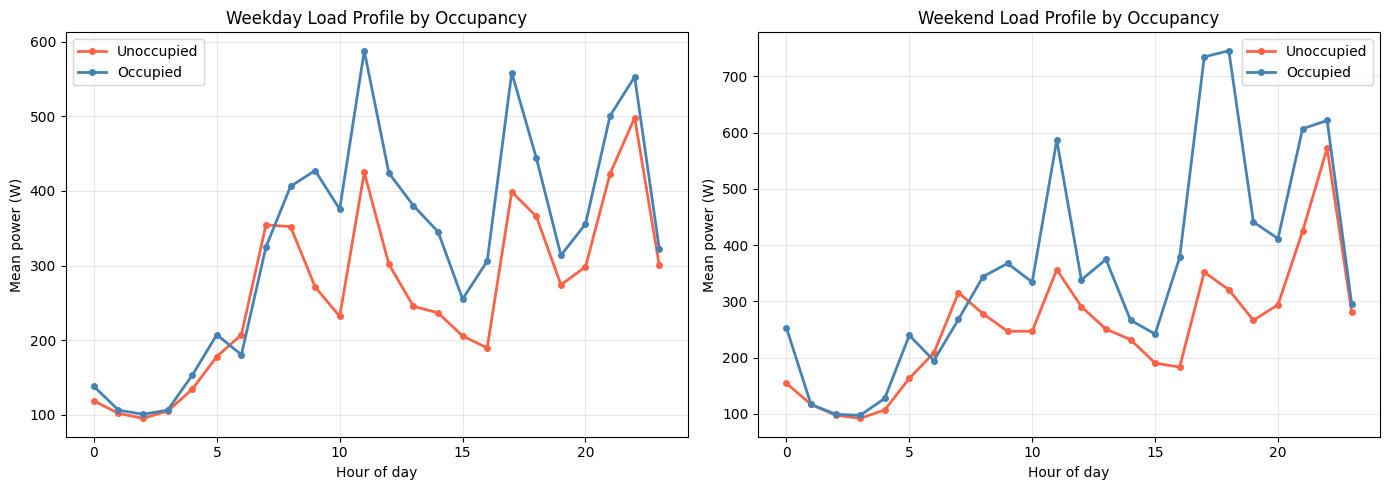

In [16]:
# Re-use house 01 df from cell 4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekday vs Weekend profiles
df['is_weekend'] = df.index.dayofweek >= 5

for ax, (day_type, label) in zip(axes, [(False, 'Weekday'), (True, 'Weekend')]):
    sub = df[df.is_weekend == day_type]
    for occ_state, color, lbl in [(0, 'tomato', 'Unoccupied'),
                                   (1, 'steelblue', 'Occupied')]:
        profile = sub[sub.occupied == occ_state].groupby('hour')['power'].mean()
        ax.plot(profile.index, profile.values, color=color, lw=2,
                marker='o', ms=4, label=lbl)
    ax.set_title(f'{label} Load Profile by Occupancy')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Mean power (W)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/eco_daily_profiles.png', dpi=120)
plt.show()

## 9. Occupancy Transition Analysis

In [55]:
for house_id, current_df in df.items():
    print(f'\n--- Occupancy Transition Analysis for House {house_id} ---')
    if current_df.empty:
        print(f'No data available for House {house_id}. Skipping transition analysis.')
        continue

    current_df['occ_change'] = current_df['occupied'].diff()

    arrivals   = current_df[current_df.occ_change ==  1].index  # 0→1 transitions
    departures = current_df[current_df.occ_change == -1].index  # 1→0 transitions

    print(f'Total arrival events:   {len(arrivals):,}')
    print(f'Total departure events: {len(departures):,}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Arrival time distribution
    ax = axes[0]
    if len(arrivals) > 0:
        arrival_hours = arrivals.hour + arrivals.minute / 60
        ax.hist(arrival_hours, bins=48, color='steelblue', alpha=0.8, edgecolor='white')
        ax.set_title(f'Arrival Times (House {house_id})')
        ax.set_xlabel('Hour of day')
        ax.set_ylabel('Count')
        mean_arrival_for_plot = np.mean(arrival_hours)
        ax.axvline(mean_arrival_for_plot, color='red', lw=2,
                   label=f'Mean: {mean_arrival_for_plot:.1f}h')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No Arrival Events', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(f'Arrival Times (House {house_id})')
        ax.set_xlabel('Hour of day')
        ax.set_ylabel('Count')

    # Departure time distribution
    ax = axes[1]
    if len(departures) > 0:
        departure_hours = departures.hour + departures.minute / 60
        ax.hist(departure_hours, bins=48, color='tomato', alpha=0.8, edgecolor='white')
        ax.set_title(f'Departure Times (House {house_id})')
        ax.set_xlabel('Hour of day')
        ax.set_ylabel('Count')
        mean_departure_for_plot = np.mean(departure_hours)
        ax.axvline(mean_departure_for_plot, color='darkred', lw=2,
                   label=f'Mean: {mean_departure_for_plot:.1f}h')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No Departure Events', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(f'Departure Times (House {house_id})')
        ax.set_xlabel('Hour of day')
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.savefig(f'/tmp/eco_transitions_house{house_id}.png', dpi=120)
    # plt.show() # Re-commented out to avoid truncation issues
    print(f'Plots for House {house_id} saved.')
    plt.close(fig)

    if len(arrivals) > 0:
        mean_arrival_val = np.mean(arrival_hours)
        print(f'\nMean arrival time:   {mean_arrival_val:.1f}h ({int(mean_arrival_val)}:{int((mean_arrival_val%1)*60):02d})')
    else:
        print('\nNo mean arrival time to display.')

    if len(departures) > 0:
        mean_departure_val = np.mean(departure_hours)
        print(f'Mean departure time: {mean_departure_val:.1f}h ({int(mean_departure_val)}:{int((mean_departure_val%1)*60):02d})')
    else:
        print('No mean departure time to display.')


--- Occupancy Transition Analysis for House 01 ---
Total arrival events:   69
Total departure events: 69
Plots for House 01 saved.

Mean arrival time:   14.1h (14:07)
Mean departure time: 10.6h (10:34)

--- Occupancy Transition Analysis for House 02 ---
Total arrival events:   166
Total departure events: 166
Plots for House 02 saved.

Mean arrival time:   14.9h (14:51)
Mean departure time: 10.9h (10:53)

--- Occupancy Transition Analysis for House 04 ---
Total arrival events:   93
Total departure events: 93
Plots for House 04 saved.

Mean arrival time:   13.7h (13:44)
Mean departure time: 12.5h (12:31)


## 10. Save Processed Data for Modelling

In [56]:
# Save 1-min resampled SM + occupancy for all 3 houses to Drive
OUT_DIR = f'{DRIVE}eco_processed'
os.makedirs(OUT_DIR, exist_ok=True)

for house_id, paths in HOUSES.items():
    print(f'Saving house {house_id}...')
    try:
        sm  = load_sm(paths['sm'])
        occ = load_occupancy(paths['occ'])
        combined = pd.DataFrame({'power_W': sm, 'occupied': occ}).dropna()
        out_path = f'{OUT_DIR}/house_{house_id}_1min.csv'
        combined.to_csv(out_path)
        print(f'  Saved {len(combined):,} rows → {out_path}')
    except Exception as e:
        print(f'  Failed: {e}')

# Save scaling stats
stats_df = pd.DataFrame(all_stats).T
stats_df.to_csv(f'{OUT_DIR}/occupancy_scaling_stats.csv')
print(f'\nScaling stats saved → {OUT_DIR}/occupancy_scaling_stats.csv')
print('\nAll done! These files will be used in the simulation engine.')

Saving house 01...
  Loading 245 SM files...
  Done: 352,800 rows at 1min resolution
  Range: 2012-06-01 00:00:00 → 2013-01-31 23:59:00
  Occupancy files: ['01_summer.csv', '01_winter.csv']
  Occupancy: 257,760 rows
  Range: 2012-07-15 00:00:00 → 2013-01-09 23:59:00
  Saved 257,760 rows → /content/drive/MyDrive/Colab_Notebooks/ECO_Dataset//eco_processed/house_01_1min.csv
Saving house 02...
  Loading 244 SM files...
  Done: 351,360 rows at 1min resolution
  Range: 2012-06-01 00:00:00 → 2013-01-31 23:59:00
  Occupancy files: ['02_summer.csv', '02_winter.csv']
  Occupancy: 332,640 rows
  Range: 2012-05-30 00:00:00 → 2013-01-15 23:59:00
  Saved 328,320 rows → /content/drive/MyDrive/Colab_Notebooks/ECO_Dataset//eco_processed/house_02_1min.csv
Saving house 04...
  Loading 219 SM files...
  Done: 315,360 rows at 1min resolution
  Range: 2012-06-27 00:00:00 → 2013-01-31 23:59:00
  Occupancy files: ['04_summer.csv', '04_winter.csv']
  Occupancy: 246,240 rows
  Range: 2012-07-25 00:00:00 → 2013-